In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

pd.set_option("display.max_columns", None)

In [2]:
DATA_PATH = "../data/raw/Telco_customer_churn.xlsx"

df = pd.read_excel(DATA_PATH)

df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [3]:
df["Total Charges"] = pd.to_numeric(
    df["Total Charges"],
    errors="coerce"
)

In [4]:
df["Total Charges"].isna().sum()

np.int64(11)

In [5]:
df.loc[
    df["Total Charges"].isna(),
    [
        "CustomerID",
        "Tenure Months",
        "Monthly Charges",
        "Total Charges"
    ]
]

,CustomerID,Tenure Months,Monthly Charges,Total Charges
2234,4472-LVYGI,0,52.55,NaN
2438,3115-CZMZD,0,20.25,NaN
2568,5709-LVOEQ,0,80.85,NaN
2667,4367-NUYAO,0,25.75,NaN
2856,1371-DWPAZ,0,56.05,NaN
4331,7644-OMVMY,0,19.85,NaN
4687,3213-VVOLG,0,25.35,NaN
5104,2520-SGTTA,0,20.00,NaN
5719,2923-ARZLG,0,19.70,NaN
6772,4075-WKNIU,0,73.35,NaN


In [6]:
pd.crosstab(
    df["Churn Label"],
    df["Churn Value"]
)

Churn Value,0,1
Churn Label,,
No,5174,0
Yes,0,1869


In [7]:
TARGET = "Churn Value"

In [8]:
leakage_columns = [
    "Churn Label",
    "Churn Score",
    "Churn Reason"
]

In [9]:
identifier_columns = [
    "CustomerID"
]

constant_columns = [
    "Count"
]

In [10]:
geographic_columns = [
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude"
]

In [11]:
drop_columns = (
    leakage_columns
    + identifier_columns
    + constant_columns
    + geographic_columns
)

In [12]:
drop_columns

['Churn Label',
 'Churn Score',
 'Churn Reason',
 'CustomerID',
 'Count',
 'Country',
 'State',
 'City',
 'Zip Code',
 'Lat Long',
 'Latitude',
 'Longitude']

In [13]:
X = df.drop(
    columns=drop_columns + [TARGET]
)

y = df[TARGET]

In [14]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 20)
y shape: (7043,)


In [15]:
X.columns.tolist()

['Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Tenure Months',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Monthly Charges',
 'Total Charges',
 'CLTV']

In [16]:
y.value_counts()

Churn Value
0    5174
1    1869
Name: count, dtype: int64

In [17]:
y.value_counts(normalize=True) * 100

Churn Value
0    73.463013
1    26.536987
Name: proportion, dtype: float64

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [19]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

In [20]:
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print()

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

X_train: (4507, 20)
X_val: (1127, 20)
X_test: (1409, 20)

y_train: (4507,)
y_val: (1127,)
y_test: (1409,)


In [21]:
print("Overall:")
print(y.value_counts(normalize=True))

print("\nTrain:")
print(y_train.value_counts(normalize=True))

print("\nValidation:")
print(y_val.value_counts(normalize=True))

print("\nTest:")
print(y_test.value_counts(normalize=True))

Overall:
Churn Value
0    0.73463
1    0.26537
Name: proportion, dtype: float64

Train:
Churn Value
0    0.734635
1    0.265365
Name: proportion, dtype: float64

Validation:
Churn Value
0    0.734694
1    0.265306
Name: proportion, dtype: float64

Test:
Churn Value
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [22]:
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

numeric_features

['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV']

In [23]:
categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

categorical_features

['Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method']

In [24]:
print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Total:", len(numeric_features) + len(categorical_features))
print("X columns:", X_train.shape[1])

Numerical features: 4
Categorical features: 16
Total: 20
X columns: 20


In [25]:
X_train[numeric_features].isna().sum()

Tenure Months      0
Monthly Charges    0
Total Charges      7
CLTV               0
dtype: int64

In [26]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [27]:
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

In [28]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numeric_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [29]:
preprocessor.fit(X_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [30]:
X_train_processed = preprocessor.transform(X_train)

In [31]:
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

In [32]:
print("Train:", X_train_processed.shape)
print("Validation:", X_val_processed.shape)
print("Test:", X_test_processed.shape)

Train: (4507, 47)
Validation: (1127, 47)
Test: (1409, 47)


In [33]:
feature_names = preprocessor.get_feature_names_out()

feature_names

array(['num__Tenure Months', 'num__Monthly Charges', 'num__Total Charges',
       'num__CLTV', 'cat__Gender_Female', 'cat__Gender_Male',
       'cat__Senior Citizen_No', 'cat__Senior Citizen_Yes',
       'cat__Partner_No', 'cat__Partner_Yes', 'cat__Dependents_No',
       'cat__Dependents_Yes', 'cat__Phone Service_No',
       'cat__Phone Service_Yes', 'cat__Multiple Lines_No',
       'cat__Multiple Lines_No phone service', 'cat__Multiple Lines_Yes',
       'cat__Internet Service_DSL', 'cat__Internet Service_Fiber optic',
       'cat__Internet Service_No', 'cat__Online Security_No',
       'cat__Online Security_No internet service',
       'cat__Online Security_Yes', 'cat__Online Backup_No',
       'cat__Online Backup_No internet service', 'cat__Online Backup_Yes',
       'cat__Device Protection_No',
       'cat__Device Protection_No internet service',
       'cat__Device Protection_Yes', 'cat__Tech Support_No',
       'cat__Tech Support_No internet service', 'cat__Tech Support_Yes',
   

In [34]:
X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)

X_train_processed_df.head()

,num__Tenure Months,num__Monthly Charges,num__Total Charges,num__CLTV,cat__Gender_Female,cat__Gender_Male,cat__Senior Citizen_No,cat__Senior Citizen_Yes,cat__Partner_No,cat__Partner_Yes,cat__Dependents_No,cat__Dependents_Yes,cat__Phone Service_No,cat__Phone Service_Yes,cat__Multiple Lines_No,cat__Multiple Lines_No phone service,cat__Multiple Lines_Yes,cat__Internet Service_DSL,cat__Internet Service_Fiber optic,cat__Internet Service_No,cat__Online Security_No,cat__Online Security_No internet service,cat__Online Security_Yes,cat__Online Backup_No,cat__Online Backup_No internet service,cat__Online Backup_Yes,cat__Device Protection_No,cat__Device Protection_No internet service,cat__Device Protection_Yes,cat__Tech Support_No,cat__Tech Support_No internet service,cat__Tech Support_Yes,cat__Streaming TV_No,cat__Streaming TV_No internet service,cat__Streaming TV_Yes,cat__Streaming Movies_No,cat__Streaming Movies_No internet service,cat__Streaming Movies_Yes,cat__Contract_Month-to-month,cat__Contract_One year,cat__Contract_Two year,cat__Paperless Billing_No,cat__Paperless Billing_Yes,cat__Payment Method_Bank transfer (automatic),cat__Payment Method_Credit card (automatic),cat__Payment Method_Electronic check,cat__Payment Method_Mailed check
6718,-0.255392,-0.174760,-0.341744,-1.994953,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2218,1.610432,1.710993,2.687266,-0.018194,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
5867,1.529309,1.652688,2.616743,-0.123395,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
152,0.677520,0.844746,0.993292,0.537504,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2191,1.610432,0.016814,1.097452,0.565501,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0


In [35]:
X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)

X_train_processed_df.head()

,num__Tenure Months,num__Monthly Charges,num__Total Charges,num__CLTV,cat__Gender_Female,cat__Gender_Male,cat__Senior Citizen_No,cat__Senior Citizen_Yes,cat__Partner_No,cat__Partner_Yes,cat__Dependents_No,cat__Dependents_Yes,cat__Phone Service_No,cat__Phone Service_Yes,cat__Multiple Lines_No,cat__Multiple Lines_No phone service,cat__Multiple Lines_Yes,cat__Internet Service_DSL,cat__Internet Service_Fiber optic,cat__Internet Service_No,cat__Online Security_No,cat__Online Security_No internet service,cat__Online Security_Yes,cat__Online Backup_No,cat__Online Backup_No internet service,cat__Online Backup_Yes,cat__Device Protection_No,cat__Device Protection_No internet service,cat__Device Protection_Yes,cat__Tech Support_No,cat__Tech Support_No internet service,cat__Tech Support_Yes,cat__Streaming TV_No,cat__Streaming TV_No internet service,cat__Streaming TV_Yes,cat__Streaming Movies_No,cat__Streaming Movies_No internet service,cat__Streaming Movies_Yes,cat__Contract_Month-to-month,cat__Contract_One year,cat__Contract_Two year,cat__Paperless Billing_No,cat__Paperless Billing_Yes,cat__Payment Method_Bank transfer (automatic),cat__Payment Method_Credit card (automatic),cat__Payment Method_Electronic check,cat__Payment Method_Mailed check
6718,-0.255392,-0.174760,-0.341744,-1.994953,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2218,1.610432,1.710993,2.687266,-0.018194,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
5867,1.529309,1.652688,2.616743,-0.123395,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
152,0.677520,0.844746,0.993292,0.537504,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2191,1.610432,0.016814,1.097452,0.565501,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0


In [36]:
np.isinf(X_train_processed).sum()

np.int64(0)

In [37]:
X_train_processed_df[
    [
        col for col in X_train_processed_df.columns
        if col.startswith("num__")
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
num__Tenure Months,4507.0,-3.547196e-17,1.000111,-1.309988,-0.944935,-0.133708,0.961450,1.610432
num__Monthly Charges,4507.0,4.666533e-16,1.000111,-1.542431,-0.971874,0.188397,0.834751,1.800950
num__Total Charges,4507.0,1.529236e-16,1.000111,-0.995221,-0.833625,-0.394735,0.670857,2.810176
num__CLTV,4507.0,1.481940e-16,1.000111,-2.054341,-0.768175,0.101429,0.831048,1.760040


In [38]:
categorical_encoded_cols = [
    col
    for col in X_train_processed_df.columns
    if col.startswith("cat__")
]

X_train_processed_df[
    categorical_encoded_cols[:10]
].head()

,cat__Gender_Female,cat__Gender_Male,cat__Senior Citizen_No,cat__Senior Citizen_Yes,cat__Partner_No,cat__Partner_Yes,cat__Dependents_No,cat__Dependents_Yes,cat__Phone Service_No,cat__Phone Service_Yes
6718,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
2218,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0
5867,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
152,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0
2191,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0


In [39]:
assert X_train_processed.shape[0] == len(y_train)
assert X_val_processed.shape[0] == len(y_val)
assert X_test_processed.shape[0] == len(y_test)

assert np.isnan(X_train_processed).sum() == 0
assert np.isnan(X_val_processed).sum() == 0
assert np.isnan(X_test_processed).sum() == 0

print("Preprocessing validation passed.")

Preprocessing validation passed.


In [40]:
assert X_train_processed.shape[0] == len(y_train)
assert X_val_processed.shape[0] == len(y_val)
assert X_test_processed.shape[0] == len(y_test)

assert np.isnan(X_train_processed).sum() == 0
assert np.isnan(X_val_processed).sum() == 0
assert np.isnan(X_test_processed).sum() == 0

print("Preprocessing validation passed.")

Preprocessing validation passed.


In [41]:
preprocessing_summary = {
    "target": TARGET,
    "dropped_columns": drop_columns,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "train_rows": len(X_train),
    "validation_rows": len(X_val),
    "test_rows": len(X_test),
    "processed_feature_count": X_train_processed.shape[1]
}

preprocessing_summary

{'target': 'Churn Value',
 'dropped_columns': ['Churn Label',
  'Churn Score',
  'Churn Reason',
  'CustomerID',
  'Count',
  'Country',
  'State',
  'City',
  'Zip Code',
  'Lat Long',
  'Latitude',
  'Longitude'],
 'numeric_features': ['Tenure Months',
  'Monthly Charges',
  'Total Charges',
  'CLTV'],
 'categorical_features': ['Gender',
  'Senior Citizen',
  'Partner',
  'Dependents',
  'Phone Service',
  'Multiple Lines',
  'Internet Service',
  'Online Security',
  'Online Backup',
  'Device Protection',
  'Tech Support',
  'Streaming TV',
  'Streaming Movies',
  'Contract',
  'Paperless Billing',
  'Payment Method'],
 'train_rows': 4507,
 'validation_rows': 1127,
 'test_rows': 1409,
 'processed_feature_count': 47}

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

In [43]:
print("Training:")
print(X_train.shape, y_train.shape)

print("\nValidation:")
print(X_val.shape, y_val.shape)

print("\nTest:")
print(X_test.shape, y_test.shape)

Training:
(4507, 20) (4507,)

Validation:
(1127, 20) (1127,)

Test:
(1409, 20) (1409,)


In [44]:
print("TRAIN")
print(y_train.value_counts(normalize=True).round(4))

print("\nVALIDATION")
print(y_val.value_counts(normalize=True).round(4))

print("\nTEST")
print(y_test.value_counts(normalize=True).round(4))

TRAIN
Churn Value
0    0.7346
1    0.2654
Name: proportion, dtype: float64

VALIDATION
Churn Value
0    0.7347
1    0.2653
Name: proportion, dtype: float64

TEST
Churn Value
0    0.7346
1    0.2654
Name: proportion, dtype: float64


In [45]:
from sklearn.dummy import DummyClassifier

dummy_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DummyClassifier(strategy="most_frequent")
        )
    ]
)

In [46]:
dummy_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['Gender','Senior Citizen','Partner',...,'Monthly Charges','Total Charges', 'CLTV']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pas

In [47]:
dummy_pred = dummy_pipeline.predict(X_val)

In [48]:
print(
    classification_report(
        y_val,
        dummy_pred,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.73      1.00      0.85       828
           1       0.00      0.00      0.00       299

    accuracy                           0.73      1127
   macro avg       0.37      0.50      0.42      1127
weighted avg       0.54      0.73      0.62      1127



In [49]:
logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

In [50]:
logistic_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['Gender','Senior Citizen','Partner',...,'Monthly Charges','Total Charges', 'CLTV']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pas

In [51]:
y_val_pred = logistic_pipeline.predict(
    X_val
)

In [52]:
y_val_prob = logistic_pipeline.predict_proba(
    X_val
)[:, 1]

In [53]:
print(y_val_pred[:10])
print(y_val_prob[:10])

[0 0 0 0 0 0 0 0 0 0]
[0.07054313 0.02082069 0.10041932 0.06886471 0.11325386 0.0116022
 0.17943402 0.00528963 0.00541362 0.21887631]


In [54]:
accuracy = accuracy_score(
    y_val,
    y_val_pred
)

print(
    f"Accuracy: {accuracy:.4f}"
)

Accuracy: 0.8234


In [55]:
precision = precision_score(
    y_val,
    y_val_pred
)

print(
    f"Precision: {precision:.4f}"
)

Precision: 0.7016


In [56]:
recall = recall_score(
    y_val,
    y_val_pred
)

print(
    f"Recall: {recall:.4f}"
)

Recall: 0.5819


In [57]:
f1 = f1_score(
    y_val,
    y_val_pred
)

print(
    f"F1 Score: {f1:.4f}"
)

F1 Score: 0.6362


In [58]:
roc_auc = roc_auc_score(
    y_val,
    y_val_prob
)

print(
    f"ROC-AUC: {roc_auc:.4f}"
)

ROC-AUC: 0.8599


In [59]:
pr_auc = average_precision_score(
    y_val,
    y_val_prob
)

print(
    f"PR-AUC: {pr_auc:.4f}"
)

PR-AUC: 0.6899


In [60]:
baseline_metrics = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(
        y_val,
        y_val_pred
    ),
    "Precision": precision_score(
        y_val,
        y_val_pred
    ),
    "Recall": recall_score(
        y_val,
        y_val_pred
    ),
    "F1": f1_score(
        y_val,
        y_val_pred
    ),
    "ROC_AUC": roc_auc_score(
        y_val,
        y_val_prob
    ),
    "PR_AUC": average_precision_score(
        y_val,
        y_val_prob
    )
}

pd.DataFrame(
    [baseline_metrics]
).round(4)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.8234,0.7016,0.5819,0.6362,0.8599,0.6899


In [61]:
print(
    classification_report(
        y_val,
        y_val_pred,
        target_names=[
            "Retained",
            "Churned"
        ]
    )
)

              precision    recall  f1-score   support

    Retained       0.86      0.91      0.88       828
     Churned       0.70      0.58      0.64       299

    accuracy                           0.82      1127
   macro avg       0.78      0.75      0.76      1127
weighted avg       0.82      0.82      0.82      1127



In [62]:
cm = confusion_matrix(
    y_val,
    y_val_pred
)

cm

array([[754,  74],
       [125, 174]])

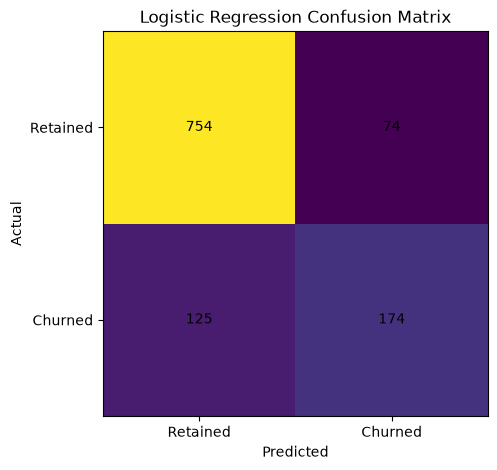

In [63]:
fig, ax = plt.subplots(
    figsize=(5, 5)
)

display_matrix = ax.imshow(cm)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(
    ["Retained", "Churned"]
)

ax.set_yticklabels(
    ["Retained", "Churned"]
)

ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

for i in range(2):
    for j in range(2):
        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.show()

In [64]:
tn, fp, fn, tp = cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

True Negatives : 754
False Positives: 74
False Negatives: 125
True Positives : 174


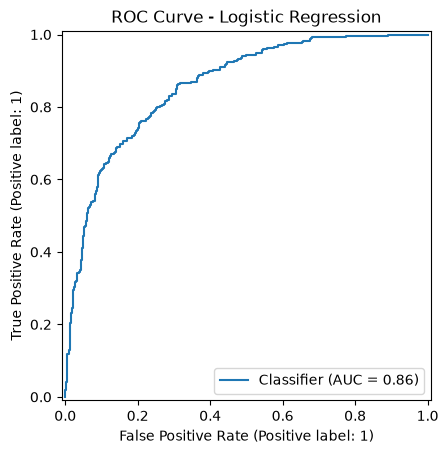

In [65]:
RocCurveDisplay.from_predictions(
    y_val,
    y_val_prob
)

plt.title(
    "ROC Curve - Logistic Regression"
)

plt.show()

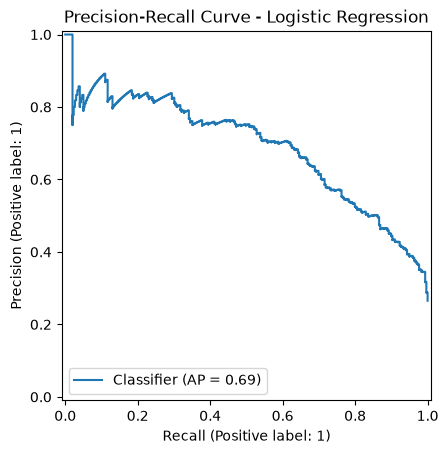

In [66]:
PrecisionRecallDisplay.from_predictions(
    y_val,
    y_val_prob
)

plt.title(
    "Precision-Recall Curve - Logistic Regression"
)

plt.show()

In [67]:
threshold_results = []

for threshold in np.arange(
    0.20,
    0.81,
    0.05
):

    predictions = (
        y_val_prob >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": round(
            threshold,
            2
        ),
        "Precision": precision_score(
            y_val,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_val,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_val,
            predictions,
            zero_division=0
        )
    })

In [68]:
threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df.round(4)

,Threshold,Precision,Recall,F1
0,0.20,0.4905,0.8662,0.6264
1,0.25,0.5241,0.7993,0.6331
2,0.30,0.5672,0.7625,0.6505
3,0.35,0.5961,0.7157,0.6505
4,0.40,0.6280,0.6890,0.6571
5,0.45,0.6748,0.6455,0.6598
6,0.50,0.7016,0.5819,0.6362
7,0.55,0.7349,0.5284,0.6148
8,0.60,0.7600,0.4448,0.5612
9,0.65,0.7840,0.3278,0.4623


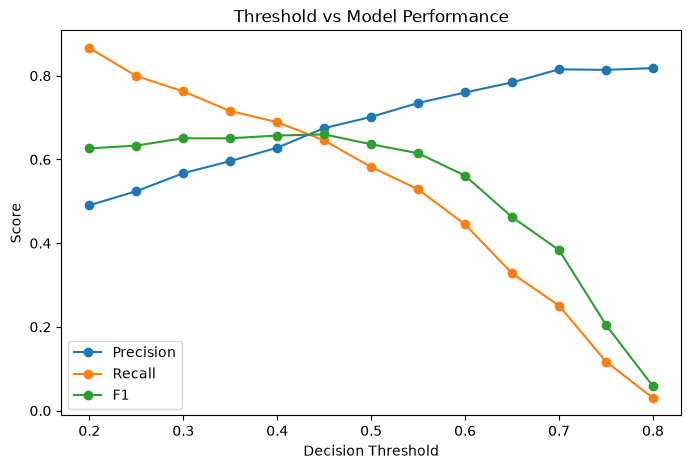

In [69]:
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")

plt.title(
    "Threshold vs Model Performance"
)

plt.legend()
plt.show()

In [70]:
best_threshold_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

best_threshold_row

Threshold    0.450000
Precision    0.674825
Recall       0.645485
F1           0.659829
Name: 5, dtype: float64

In [71]:
weighted_logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

In [72]:
weighted_logistic_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['Gender','Senior Citizen','Partner',...,'Monthly Charges','Total Charges', 'CLTV']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pas

In [73]:
weighted_val_pred = (
    weighted_logistic_pipeline.predict(
        X_val
    )
)

weighted_val_prob = (
    weighted_logistic_pipeline.predict_proba(
        X_val
    )[:, 1]
)

In [74]:
weighted_metrics = {
    "Model": "Logistic Regression Balanced",
    "Accuracy": accuracy_score(
        y_val,
        weighted_val_pred
    ),
    "Precision": precision_score(
        y_val,
        weighted_val_pred
    ),
    "Recall": recall_score(
        y_val,
        weighted_val_pred
    ),
    "F1": f1_score(
        y_val,
        weighted_val_pred
    ),
    "ROC_AUC": roc_auc_score(
        y_val,
        weighted_val_prob
    ),
    "PR_AUC": average_precision_score(
        y_val,
        weighted_val_prob
    )
}

pd.DataFrame(
    [weighted_metrics]
).round(4)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression Balanced,0.764,0.5376,0.7893,0.6396,0.86,0.6929


In [75]:
model_comparison = pd.DataFrame([
    baseline_metrics,
    weighted_metrics
])

model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.8234,0.7016,0.5819,0.6362,0.8599,0.6899
1,Logistic Regression Balanced,0.7640,0.5376,0.7893,0.6396,0.8600,0.6929


In [76]:
print("NORMAL LOGISTIC REGRESSION")
print(
    confusion_matrix(
        y_val,
        y_val_pred
    )
)

print("\nBALANCED LOGISTIC REGRESSION")
print(
    confusion_matrix(
        y_val,
        weighted_val_pred
    )
)

NORMAL LOGISTIC REGRESSION
[[754  74]
 [125 174]]

BALANCED LOGISTIC REGRESSION
[[625 203]
 [ 63 236]]


In [77]:
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [78]:
candidate_models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        random_state=42,
        eval_metric="logloss"
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        random_state=42
    ),

    "CatBoost": CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        random_state=42,
        verbose=0
    )
}

In [79]:
results = [
    baseline_metrics,
    weighted_metrics
]

trained_models = {
    "Logistic Regression":
        logistic_pipeline,

    "Logistic Regression Balanced":
        weighted_logistic_pipeline
}

for model_name, classifier in candidate_models.items():

    pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "classifier",
                classifier
            )
        ]
    )

    pipeline.fit(
        X_train,
        y_train
    )

    predictions = pipeline.predict(
        X_val
    )

    probabilities = (
        pipeline.predict_proba(
            X_val
        )[:, 1]
    )

    metrics = {
        "Model": model_name,

        "Accuracy":
            accuracy_score(
                y_val,
                predictions
            ),

        "Precision":
            precision_score(
                y_val,
                predictions
            ),

        "Recall":
            recall_score(
                y_val,
                predictions
            ),

        "F1":
            f1_score(
                y_val,
                predictions
            ),

        "ROC_AUC":
            roc_auc_score(
                y_val,
                probabilities
            ),

        "PR_AUC":
            average_precision_score(
                y_val,
                probabilities
            )
    }

    results.append(metrics)

    trained_models[
        model_name
    ] = pipeline

[LightGBM] [Info] Number of positive: 1196, number of negative: 3311
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000261 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 925
[LightGBM] [Info] Number of data points in the train set: 4507, number of used features: 47
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265365 -> initscore=-1.018268
[LightGBM] [Info] Start training from score -1.018268


In [80]:
results_df = (
    pd.DataFrame(results)
    .sort_values(
        by="F1",
        ascending=False
    )
    .reset_index(drop=True)
)

results_df.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression Balanced,0.7640,0.5376,0.7893,0.6396,0.8600,0.6929
1,Logistic Regression,0.8234,0.7016,0.5819,0.6362,0.8599,0.6899
2,Random Forest,0.7906,0.5929,0.6722,0.6301,0.8518,0.6490
3,CatBoost,0.8128,0.6913,0.5318,0.6011,0.8649,0.6799
4,LightGBM,0.8048,0.6599,0.5452,0.5971,0.8589,0.6783
5,XGBoost,0.8057,0.6639,0.5418,0.5967,0.8624,0.6855


In [81]:
results_df.sort_values(
    by="PR_AUC",
    ascending=False
).round(4)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression Balanced,0.7640,0.5376,0.7893,0.6396,0.8600,0.6929
1,Logistic Regression,0.8234,0.7016,0.5819,0.6362,0.8599,0.6899
5,XGBoost,0.8057,0.6639,0.5418,0.5967,0.8624,0.6855
3,CatBoost,0.8128,0.6913,0.5318,0.6011,0.8649,0.6799
4,LightGBM,0.8048,0.6599,0.5452,0.5971,0.8589,0.6783
2,Random Forest,0.7906,0.5929,0.6722,0.6301,0.8518,0.6490


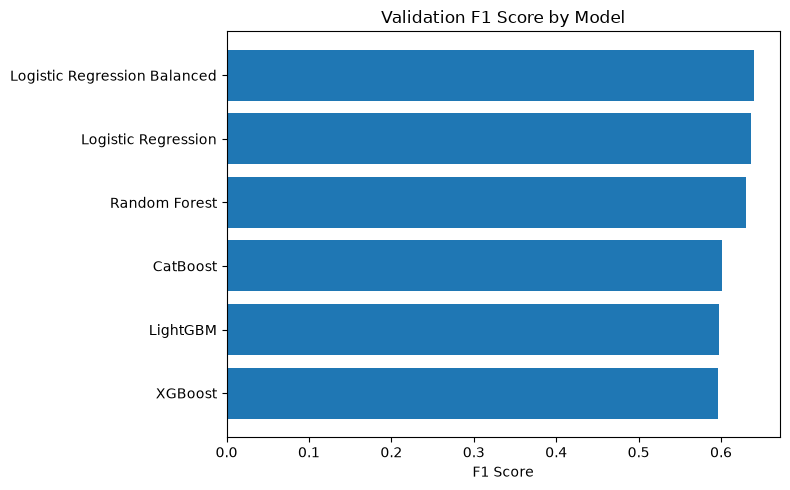

In [82]:
plot_df = results_df.sort_values(
    "F1"
)

plt.figure(
    figsize=(8, 5)
)

plt.barh(
    plot_df["Model"],
    plot_df["F1"]
)

plt.xlabel("F1 Score")
plt.title(
    "Validation F1 Score by Model"
)

plt.tight_layout()
plt.show()

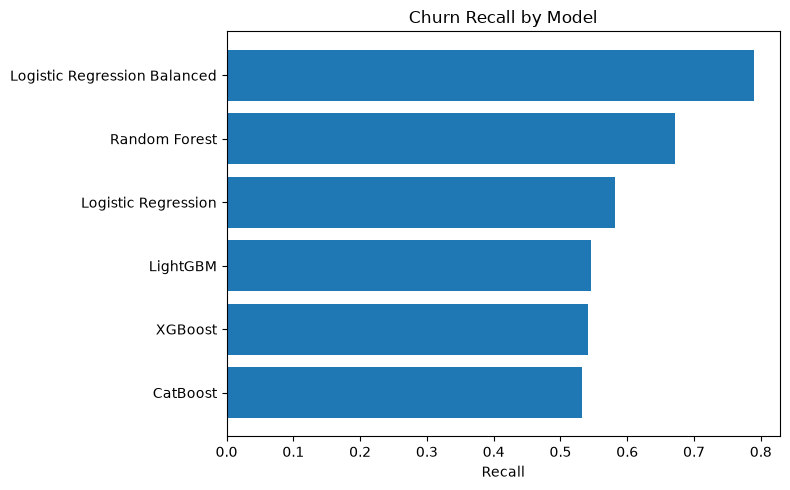

In [83]:
plot_df = results_df.sort_values(
    "Recall"
)

plt.figure(
    figsize=(8, 5)
)

plt.barh(
    plot_df["Model"],
    plot_df["Recall"]
)

plt.xlabel("Recall")
plt.title(
    "Churn Recall by Model"
)

plt.tight_layout()
plt.show()

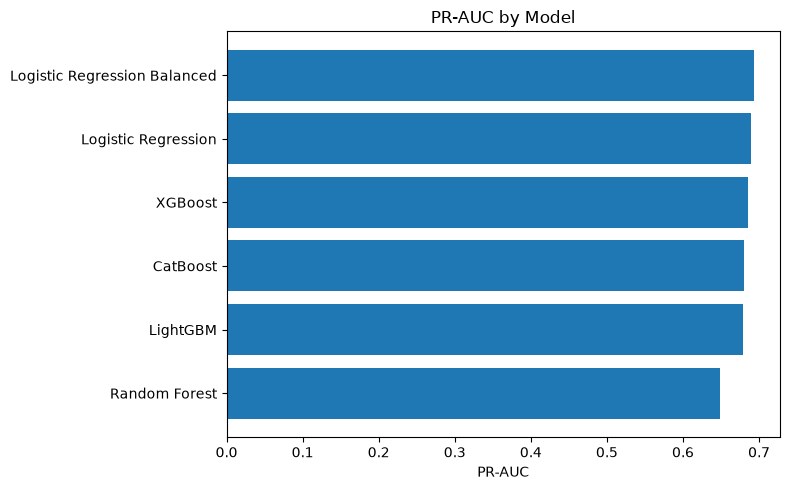

In [84]:
plot_df = results_df.sort_values(
    "PR_AUC"
)

plt.figure(
    figsize=(8, 5)
)

plt.barh(
    plot_df["Model"],
    plot_df["PR_AUC"]
)

plt.xlabel("PR-AUC")
plt.title(
    "PR-AUC by Model"
)

plt.tight_layout()
plt.show()

In [85]:
best_model_name = (
    results_df
    .sort_values(
        "F1",
        ascending=False
    )
    .iloc[0]["Model"]
)

print(
    "Best current model:",
    best_model_name
)

Best current model: Logistic Regression Balanced


In [86]:
X_train_fe = X_train.copy()
X_val_fe = X_val.copy()
X_test_fe = X_test.copy()

In [87]:
def add_engineered_features(df):
    df = df.copy()

    service_cols = [
        "Phone Service",
        "Online Security",
        "Online Backup",
        "Device Protection",
        "Tech Support",
        "Streaming TV",
        "Streaming Movies"
    ]

    df["NumberOfServices"] = (
        df[service_cols]
        .eq("Yes")
        .sum(axis=1)
    )

    df["IsMonthToMonth"] = (
        df["Contract"] == "Month-to-month"
    ).astype(int)

    df["HasTechSupport"] = (
        df["Tech Support"] == "Yes"
    ).astype(int)

    df["HasOnlineSecurity"] = (
        df["Online Security"] == "Yes"
    ).astype(int)

    df["HasPartnerOrDependents"] = (
        (df["Partner"] == "Yes") |
        (df["Dependents"] == "Yes")
    ).astype(int)

    df["AvgMonthlySpend"] = (
        df["Total Charges"] /
        df["Tenure Months"].replace(0, 1)
    )

    df["ChargesPerService"] = (
        df["Monthly Charges"] /
        df["NumberOfServices"].replace(0, 1)
    )

    return df

In [88]:
X_train_fe = add_engineered_features(X_train)
X_val_fe = add_engineered_features(X_val)
X_test_fe = add_engineered_features(X_test)

print(X_train.shape)
print(X_train_fe.shape)

(4507, 20)
(4507, 27)


In [89]:
new_features = [
    col for col in X_train_fe.columns
    if col not in X_train.columns
]

new_features

['NumberOfServices',
 'IsMonthToMonth',
 'HasTechSupport',
 'HasOnlineSecurity',
 'HasPartnerOrDependents',
 'AvgMonthlySpend',
 'ChargesPerService']

In [90]:
numeric_features_fe = X_train_fe.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features_fe = X_train_fe.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical:", numeric_features_fe)
print("Categorical:", categorical_features_fe)

Numerical: ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV', 'NumberOfServices', 'IsMonthToMonth', 'HasTechSupport', 'HasOnlineSecurity', 'HasPartnerOrDependents', 'AvgMonthlySpend', 'ChargesPerService']
Categorical: ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']


In [91]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_pipeline_fe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline_fe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

preprocessor_fe = ColumnTransformer([
    (
        "num",
        numeric_pipeline_fe,
        numeric_features_fe
    ),
    (
        "cat",
        categorical_pipeline_fe,
        categorical_features_fe
    )
])

In [92]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

candidate_models_fe = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

    "Logistic Regression Balanced": LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        random_state=42,
        eval_metric="logloss"
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        random_state=42
    ),

    "CatBoost": CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        random_state=42,
        verbose=0
    )
}

In [93]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

feature_results = []
feature_models = {}

for model_name, classifier in candidate_models_fe.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor_fe),
        ("classifier", classifier)
    ])

    pipeline.fit(
        X_train_fe,
        y_train
    )

    y_pred = pipeline.predict(
        X_val_fe
    )

    y_prob = pipeline.predict_proba(
        X_val_fe
    )[:, 1]

    feature_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_val,
            y_pred
        ),
        "Precision": precision_score(
            y_val,
            y_pred
        ),
        "Recall": recall_score(
            y_val,
            y_pred
        ),
        "F1": f1_score(
            y_val,
            y_pred
        ),
        "ROC_AUC": roc_auc_score(
            y_val,
            y_prob
        ),
        "PR_AUC": average_precision_score(
            y_val,
            y_prob
        )
    })

    feature_models[model_name] = pipeline

[LightGBM] [Info] Number of positive: 1196, number of negative: 3311
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000271 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1456
[LightGBM] [Info] Number of data points in the train set: 4507, number of used features: 54
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265365 -> initscore=-1.018268
[LightGBM] [Info] Start training from score -1.018268


In [94]:
feature_results_df = (
    pd.DataFrame(feature_results)
    .sort_values(
        "F1",
        ascending=False
    )
    .reset_index(drop=True)
)

feature_results_df.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression Balanced,0.7746,0.5510,0.8127,0.6568,0.8637,0.6956
1,Logistic Regression,0.8279,0.7108,0.5920,0.6460,0.8638,0.6942
2,Random Forest,0.7888,0.5894,0.6722,0.6281,0.8522,0.6591
3,CatBoost,0.8137,0.6926,0.5351,0.6038,0.8642,0.6819
4,XGBoost,0.8048,0.6639,0.5351,0.5926,0.8568,0.6758
5,LightGBM,0.8030,0.6571,0.5385,0.5919,0.8551,0.6643


In [95]:
baseline_results_df = pd.DataFrame([
    {
        "Model": "Logistic Regression Balanced",
        "Accuracy": 0.7640,
        "Precision": 0.5376,
        "Recall": 0.7893,
        "F1": 0.6396,
        "ROC_AUC": 0.8600,
        "PR_AUC": 0.6929
    },
    {
        "Model": "Logistic Regression",
        "Accuracy": 0.8234,
        "Precision": 0.7016,
        "Recall": 0.5819,
        "F1": 0.6362,
        "ROC_AUC": 0.8599,
        "PR_AUC": 0.6899
    },
    {
        "Model": "Random Forest",
        "Accuracy": 0.7906,
        "Precision": 0.5929,
        "Recall": 0.6722,
        "F1": 0.6301,
        "ROC_AUC": 0.8518,
        "PR_AUC": 0.6490
    },
    {
        "Model": "CatBoost",
        "Accuracy": 0.8128,
        "Precision": 0.6913,
        "Recall": 0.5318,
        "F1": 0.6011,
        "ROC_AUC": 0.8649,
        "PR_AUC": 0.6799
    },
    {
        "Model": "LightGBM",
        "Accuracy": 0.8048,
        "Precision": 0.6599,
        "Recall": 0.5452,
        "F1": 0.5971,
        "ROC_AUC": 0.8589,
        "PR_AUC": 0.6783
    },
    {
        "Model": "XGBoost",
        "Accuracy": 0.8057,
        "Precision": 0.6639,
        "Recall": 0.5418,
        "F1": 0.5967,
        "ROC_AUC": 0.8624,
        "PR_AUC": 0.6855
    }
])

In [96]:
comparison = baseline_results_df.merge(
    feature_results_df,
    on="Model",
    suffixes=("_Baseline", "_FeatureEng")
)

comparison["F1_Change"] = (
    comparison["F1_FeatureEng"]
    - comparison["F1_Baseline"]
)

comparison["Recall_Change"] = (
    comparison["Recall_FeatureEng"]
    - comparison["Recall_Baseline"]
)

comparison["PR_AUC_Change"] = (
    comparison["PR_AUC_FeatureEng"]
    - comparison["PR_AUC_Baseline"]
)

comparison[
    [
        "Model",
        "F1_Baseline",
        "F1_FeatureEng",
        "F1_Change",
        "Recall_Baseline",
        "Recall_FeatureEng",
        "Recall_Change",
        "PR_AUC_Baseline",
        "PR_AUC_FeatureEng",
        "PR_AUC_Change"
    ]
].round(4)

,Model,F1_Baseline,F1_FeatureEng,F1_Change,Recall_Baseline,Recall_FeatureEng,Recall_Change,PR_AUC_Baseline,PR_AUC_FeatureEng,PR_AUC_Change
0,Logistic Regression Balanced,0.6396,0.6568,0.0172,0.7893,0.8127,0.0234,0.6929,0.6956,0.0027
1,Logistic Regression,0.6362,0.6460,0.0098,0.5819,0.5920,0.0101,0.6899,0.6942,0.0043
2,Random Forest,0.6301,0.6281,-0.0020,0.6722,0.6722,0.0000,0.6490,0.6591,0.0101
3,CatBoost,0.6011,0.6038,0.0027,0.5318,0.5351,0.0033,0.6799,0.6819,0.0020
4,LightGBM,0.5971,0.5919,-0.0052,0.5452,0.5385,-0.0067,0.6783,0.6643,-0.0140
5,XGBoost,0.5967,0.5926,-0.0041,0.5418,0.5351,-0.0067,0.6855,0.6758,-0.0097


In [97]:
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [98]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [99]:
scoring = {
    "f1": "f1",
    "recall": "recall",
    "precision": "precision",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

In [100]:
lr_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor_fe
    ),
    (
        "classifier",
        LogisticRegression(
            class_weight="balanced",
            max_iter=3000,
            random_state=42
        )
    )
])

In [101]:
lr_param_grid = {
    "classifier__C": [
        0.001,
        0.01,
        0.05,
        0.1,
        0.5,
        1,
        2,
        5,
        10,
        50,
        100
    ],

    "classifier__solver": [
        "liblinear",
        "lbfgs"
    ]
}

In [102]:
lr_search = RandomizedSearchCV(
    estimator=lr_pipeline,
    param_distributions=lr_param_grid,
    n_iter=15,
    scoring=scoring,
    refit="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

In [103]:
lr_search.fit(
    X_train_fe,
    y_train
)

Fitting 5 folds for each of 15 candidates, totalling 75 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__C': [0.001, 0.01, ...], 'classifier__solver': ['liblinear', 'lbfgs']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","{'f1': 'f1', 'pr_auc': 'average_precision', 'precision': 'precision', 'recall': 'recall', ...}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuff

In [104]:
lr_search.best_params_

{'classifier__solver': 'liblinear', 'classifier__C': 100}

In [105]:
print(
    "Best CV F1:",
    round(lr_search.best_score_, 4)
)

Best CV F1: 0.6462


In [106]:
best_lr = lr_search.best_estimator_

In [107]:
lr_val_pred = best_lr.predict(
    X_val_fe
)

lr_val_prob = best_lr.predict_proba(
    X_val_fe
)[:, 1]

In [108]:
tuned_lr_metrics = {
    "Model": "Tuned Logistic Balanced",

    "Accuracy": accuracy_score(
        y_val,
        lr_val_pred
    ),

    "Precision": precision_score(
        y_val,
        lr_val_pred
    ),

    "Recall": recall_score(
        y_val,
        lr_val_pred
    ),

    "F1": f1_score(
        y_val,
        lr_val_pred
    ),

    "ROC_AUC": roc_auc_score(
        y_val,
        lr_val_prob
    ),

    "PR_AUC": average_precision_score(
        y_val,
        lr_val_prob
    )
}

pd.DataFrame(
    [tuned_lr_metrics]
).round(4)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Tuned Logistic Balanced,0.7711,0.5461,0.8127,0.6532,0.8643,0.6965


In [109]:
xgb_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor_fe
    ),
    (
        "classifier",
        XGBClassifier(
            random_state=42,
            eval_metric="logloss",
            n_jobs=-1
        )
    )
])

In [110]:
xgb_param_grid = {
    "classifier__n_estimators": [
        100,
        200,
        300,
        500
    ],

    "classifier__max_depth": [
        2,
        3,
        4,
        5,
        6
    ],

    "classifier__learning_rate": [
        0.01,
        0.03,
        0.05,
        0.1,
        0.2
    ],

    "classifier__subsample": [
        0.7,
        0.8,
        0.9,
        1.0
    ],

    "classifier__colsample_bytree": [
        0.7,
        0.8,
        0.9,
        1.0
    ],

    "classifier__min_child_weight": [
        1,
        3,
        5,
        7
    ]
}

In [111]:
xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_param_grid,
    n_iter=30,
    scoring=scoring,
    refit="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

In [112]:
xgb_search.fit(
    X_train_fe,
    y_train
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__colsample_bytree': [0.7, 0.8, ...], 'classifier__learning_rate': [0.01, 0.03, ...], 'classifier__max_depth': [2, 3, ...], 'classifier__min_child_weight': [1, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","{'f1': 'f1', 'pr_auc': 'average_precision', 'precision': 'precision', 'recall': 'recall', ...}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`Stratifi

In [113]:
xgb_search.best_params_

{'classifier__subsample': 1.0,
 'classifier__n_estimators': 200,
 'classifier__min_child_weight': 1,
 'classifier__max_depth': 3,
 'classifier__learning_rate': 0.03,
 'classifier__colsample_bytree': 1.0}

In [114]:
print(
    "Best XGBoost CV F1:",
    round(xgb_search.best_score_, 4)
)

Best XGBoost CV F1: 0.6024


In [115]:
best_xgb = xgb_search.best_estimator_

In [116]:
xgb_val_pred = best_xgb.predict(
    X_val_fe
)

xgb_val_prob = best_xgb.predict_proba(
    X_val_fe
)[:, 1]

In [117]:
tuned_xgb_metrics = {
    "Model": "Tuned XGBoost",

    "Accuracy": accuracy_score(
        y_val,
        xgb_val_pred
    ),

    "Precision": precision_score(
        y_val,
        xgb_val_pred
    ),

    "Recall": recall_score(
        y_val,
        xgb_val_pred
    ),

    "F1": f1_score(
        y_val,
        xgb_val_pred
    ),

    "ROC_AUC": roc_auc_score(
        y_val,
        xgb_val_prob
    ),

    "PR_AUC": average_precision_score(
        y_val,
        xgb_val_prob
    )
}

pd.DataFrame(
    [tuned_xgb_metrics]
).round(4)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Tuned XGBoost,0.8217,0.7168,0.5418,0.6171,0.8666,0.6916


In [118]:
cat_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor_fe
    ),
    (
        "classifier",
        CatBoostClassifier(
            random_state=42,
            verbose=0
        )
    )
])

In [119]:
cat_param_grid = {
    "classifier__iterations": [
        100,
        200,
        300,
        500
    ],

    "classifier__depth": [
        4,
        5,
        6,
        7,
        8
    ],

    "classifier__learning_rate": [
        0.01,
        0.03,
        0.05,
        0.1,
        0.2
    ],

    "classifier__l2_leaf_reg": [
        1,
        3,
        5,
        7,
        10
    ]
}

In [120]:
cat_search = RandomizedSearchCV(
    estimator=cat_pipeline,
    param_distributions=cat_param_grid,
    n_iter=25,
    scoring=scoring,
    refit="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

In [121]:
cat_search.fit(
    X_train_fe,
    y_train
)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step... verbose=0))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__depth': [4, 5, ...], 'classifier__iterations': [100, 200, ...], 'classifier__l2_leaf_reg': [1, 3, ...], 'classifier__learning_rate': [0.01, 0.03, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",25
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","{'f1': 'f1', 'pr_auc': 'average_precision', 'precision': 'precision', 'recall': 'recall', ...}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In a

In [122]:
cat_search.best_params_

{'classifier__learning_rate': 0.01,
 'classifier__l2_leaf_reg': 7,
 'classifier__iterations': 500,
 'classifier__depth': 8}

In [123]:
print(
    "Best CatBoost CV F1:",
    round(cat_search.best_score_, 4)
)

Best CatBoost CV F1: 0.6026


In [124]:
best_cat = cat_search.best_estimator_

In [125]:
cat_val_pred = best_cat.predict(
    X_val_fe
)

cat_val_prob = best_cat.predict_proba(
    X_val_fe
)[:, 1]

In [126]:
tuned_cat_metrics = {
    "Model": "Tuned CatBoost",

    "Accuracy": accuracy_score(
        y_val,
        cat_val_pred
    ),

    "Precision": precision_score(
        y_val,
        cat_val_pred
    ),

    "Recall": recall_score(
        y_val,
        cat_val_pred
    ),

    "F1": f1_score(
        y_val,
        cat_val_pred
    ),

    "ROC_AUC": roc_auc_score(
        y_val,
        cat_val_prob
    ),

    "PR_AUC": average_precision_score(
        y_val,
        cat_val_prob
    )
}

pd.DataFrame(
    [tuned_cat_metrics]
).round(4)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Tuned CatBoost,0.8208,0.71,0.5485,0.6189,0.8667,0.6878


In [127]:
tuned_results = pd.DataFrame([
    tuned_lr_metrics,
    tuned_xgb_metrics,
    tuned_cat_metrics
])

tuned_results.sort_values(
    "F1",
    ascending=False
).round(4)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Tuned Logistic Balanced,0.7711,0.5461,0.8127,0.6532,0.8643,0.6965
2,Tuned CatBoost,0.8208,0.7100,0.5485,0.6189,0.8667,0.6878
1,Tuned XGBoost,0.8217,0.7168,0.5418,0.6171,0.8666,0.6916


In [128]:
pre_tuning = pd.DataFrame([
    {
        "Model": "Logistic Balanced + FE",
        "F1": 0.6568,
        "Recall": 0.8127,
        "PR_AUC": 0.6956
    },

    {
        "Model": "XGBoost + FE",
        "F1": 0.5926,
        "Recall": 0.5351,
        "PR_AUC": 0.6758
    },

    {
        "Model": "CatBoost + FE",
        "F1": 0.6038,
        "Recall": 0.5351,
        "PR_AUC": 0.6819
    }
])

pre_tuning

,Model,F1,Recall,PR_AUC
0,Logistic Balanced + FE,0.6568,0.8127,0.6956
1,XGBoost + FE,0.5926,0.5351,0.6758
2,CatBoost + FE,0.6038,0.5351,0.6819


In [129]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [130]:
def evaluate_thresholds(
    y_true,
    probabilities,
    model_name,
    start=0.10,
    end=0.90,
    step=0.01
):
    results = []

    for threshold in np.arange(start, end + step, step):

        predictions = (
            probabilities >= threshold
        ).astype(int)

        results.append({
            "Model": model_name,
            "Threshold": round(threshold, 2),
            "Precision": precision_score(
                y_true,
                predictions,
                zero_division=0
            ),
            "Recall": recall_score(
                y_true,
                predictions,
                zero_division=0
            ),
            "F1": f1_score(
                y_true,
                predictions,
                zero_division=0
            )
        })

    return pd.DataFrame(results)

In [131]:
lr_threshold_df = evaluate_thresholds(
    y_val,
    lr_val_prob,
    "Logistic Balanced"
)

lr_threshold_df.head()

,Model,Threshold,Precision,Recall,F1
0,Logistic Balanced,0.10,0.354567,0.986622,0.521662
1,Logistic Balanced,0.11,0.358629,0.979933,0.525090
2,Logistic Balanced,0.12,0.365457,0.976589,0.531876
3,Logistic Balanced,0.13,0.366834,0.976589,0.533333
4,Logistic Balanced,0.14,0.372423,0.966555,0.537674


In [132]:
best_lr_threshold = lr_threshold_df.loc[
    lr_threshold_df["F1"].idxmax()
]

best_lr_threshold

Model        Logistic Balanced
Threshold                 0.51
Precision             0.554795
Recall                0.812709
F1                     0.65943
Name: 41, dtype: object

In [133]:
xgb_threshold_df = evaluate_thresholds(
    y_val,
    xgb_val_prob,
    "XGBoost"
)

best_xgb_threshold = xgb_threshold_df.loc[
    xgb_threshold_df["F1"].idxmax()
]

best_xgb_threshold

Model         XGBoost
Threshold        0.36
Precision    0.609418
Recall       0.735786
F1           0.666667
Name: 26, dtype: object

In [134]:
cat_threshold_df = evaluate_thresholds(
    y_val,
    cat_val_prob,
    "CatBoost"
)

best_cat_threshold = cat_threshold_df.loc[
    cat_threshold_df["F1"].idxmax()
]

best_cat_threshold

Model        CatBoost
Threshold        0.35
Precision    0.603217
Recall       0.752508
F1           0.669643
Name: 25, dtype: object

In [135]:
best_threshold_results = pd.DataFrame([
    best_lr_threshold,
    best_xgb_threshold,
    best_cat_threshold
])

best_threshold_results.sort_values(
    "F1",
    ascending=False
).round(4)

,Model,Threshold,Precision,Recall,F1
25,CatBoost,0.35,0.6032,0.7525,0.6696
26,XGBoost,0.36,0.6094,0.7358,0.6667
41,Logistic Balanced,0.51,0.5548,0.8127,0.6594


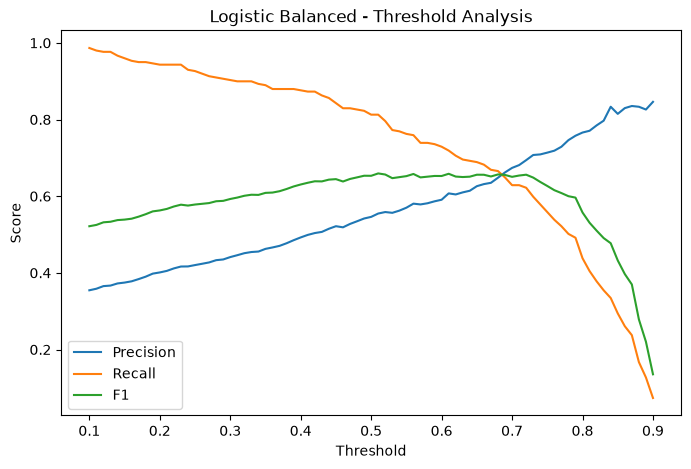

In [136]:
plt.figure(figsize=(8, 5))

plt.plot(
    lr_threshold_df["Threshold"],
    lr_threshold_df["Precision"],
    label="Precision"
)

plt.plot(
    lr_threshold_df["Threshold"],
    lr_threshold_df["Recall"],
    label="Recall"
)

plt.plot(
    lr_threshold_df["Threshold"],
    lr_threshold_df["F1"],
    label="F1"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Logistic Balanced - Threshold Analysis")
plt.legend()
plt.show()

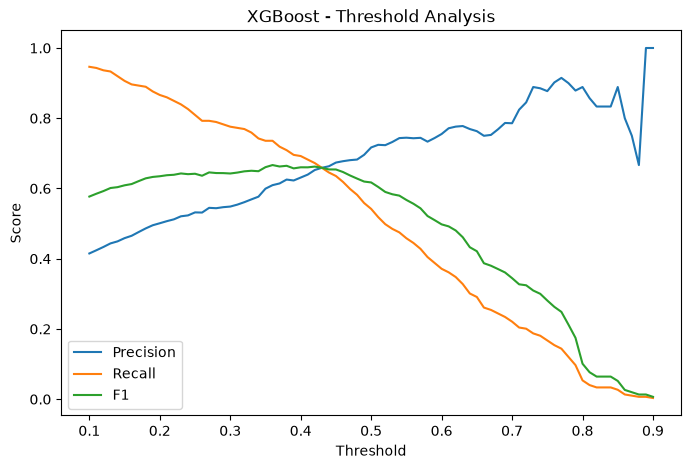

In [137]:
plt.figure(figsize=(8, 5))

plt.plot(
    xgb_threshold_df["Threshold"],
    xgb_threshold_df["Precision"],
    label="Precision"
)

plt.plot(
    xgb_threshold_df["Threshold"],
    xgb_threshold_df["Recall"],
    label="Recall"
)

plt.plot(
    xgb_threshold_df["Threshold"],
    xgb_threshold_df["F1"],
    label="F1"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("XGBoost - Threshold Analysis")
plt.legend()
plt.show()

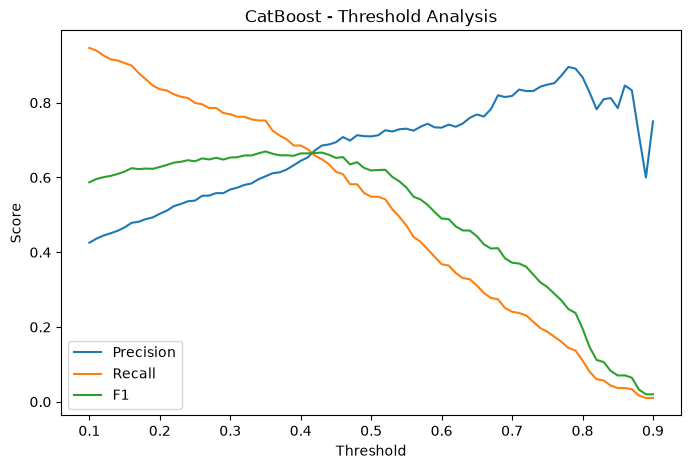

In [138]:
plt.figure(figsize=(8, 5))

plt.plot(
    cat_threshold_df["Threshold"],
    cat_threshold_df["Precision"],
    label="Precision"
)

plt.plot(
    cat_threshold_df["Threshold"],
    cat_threshold_df["Recall"],
    label="Recall"
)

plt.plot(
    cat_threshold_df["Threshold"],
    cat_threshold_df["F1"],
    label="F1"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("CatBoost - Threshold Analysis")
plt.legend()
plt.show()

In [139]:
lr_business_thresholds = (
    lr_threshold_df[
        lr_threshold_df["Recall"] >= 0.75
    ]
    .sort_values(
        "Precision",
        ascending=False
    )
)

lr_business_thresholds.head(10).round(4)

,Model,Threshold,Precision,Recall,F1
46,Logistic Balanced,0.56,0.5806,0.7592,0.6580
45,Logistic Balanced,0.55,0.5700,0.7625,0.6524
44,Logistic Balanced,0.54,0.5623,0.7692,0.6497
42,Logistic Balanced,0.52,0.5587,0.7960,0.6566
43,Logistic Balanced,0.53,0.5566,0.7726,0.6471
41,Logistic Balanced,0.51,0.5548,0.8127,0.6594
40,Logistic Balanced,0.50,0.5461,0.8127,0.6532
39,Logistic Balanced,0.49,0.5419,0.8227,0.6534
38,Logistic Balanced,0.48,0.5346,0.8261,0.6491
37,Logistic Balanced,0.47,0.5277,0.8294,0.6450


In [140]:
xgb_business_thresholds = (
    xgb_threshold_df[
        xgb_threshold_df["Recall"] >= 0.75
    ]
    .sort_values(
        "Precision",
        ascending=False
    )
)

xgb_business_thresholds.head(10).round(4)

,Model,Threshold,Precision,Recall,F1
23,XGBoost,0.33,0.5689,0.7592,0.6504
22,XGBoost,0.32,0.5610,0.7692,0.6488
21,XGBoost,0.31,0.5540,0.7726,0.6453
20,XGBoost,0.30,0.5485,0.7759,0.6427
19,XGBoost,0.29,0.5467,0.7826,0.6437
17,XGBoost,0.27,0.5448,0.7926,0.6458
18,XGBoost,0.28,0.5438,0.7893,0.6439
15,XGBoost,0.25,0.5319,0.8094,0.6419
16,XGBoost,0.26,0.5314,0.7926,0.6362
14,XGBoost,0.24,0.5233,0.8261,0.6407


In [141]:
cat_business_thresholds = (
    cat_threshold_df[
        cat_threshold_df["Recall"] >= 0.75
    ]
    .sort_values(
        "Precision",
        ascending=False
    )
)

cat_business_thresholds.head(10).round(4)

,Model,Threshold,Precision,Recall,F1
25,CatBoost,0.35,0.6032,0.7525,0.6696
24,CatBoost,0.34,0.5952,0.7525,0.6647
23,CatBoost,0.33,0.5840,0.7559,0.6589
22,CatBoost,0.32,0.5802,0.7625,0.6590
21,CatBoost,0.31,0.5729,0.7625,0.6542
20,CatBoost,0.30,0.5679,0.7692,0.6534
18,CatBoost,0.28,0.5582,0.7860,0.6528
19,CatBoost,0.29,0.5580,0.7726,0.6480
17,CatBoost,0.27,0.5516,0.7860,0.6483
16,CatBoost,0.26,0.5509,0.7960,0.6512


In [142]:
validation_champions = pd.DataFrame([
    best_lr_threshold,
    best_xgb_threshold,
    best_cat_threshold
])

validation_champions = (
    validation_champions
    .sort_values(
        "F1",
        ascending=False
    )
    .reset_index(drop=True)
)

validation_champions.round(4)

,Model,Threshold,Precision,Recall,F1
0,CatBoost,0.35,0.6032,0.7525,0.6696
1,XGBoost,0.36,0.6094,0.7358,0.6667
2,Logistic Balanced,0.51,0.5548,0.8127,0.6594


In [143]:
champion_row = validation_champions.iloc[0]

champion_model_name = champion_row["Model"]
champion_threshold = champion_row["Threshold"]

print("Champion model:", champion_model_name)
print("Selected threshold:", champion_threshold)
print("Validation F1:", round(champion_row["F1"], 4))
print("Validation Recall:", round(champion_row["Recall"], 4))
print("Validation Precision:", round(champion_row["Precision"], 4))

Champion model: CatBoost
Selected threshold: 0.35
Validation F1: 0.6696
Validation Recall: 0.7525
Validation Precision: 0.6032


In [144]:
model_map = {
    "Logistic Balanced": best_lr,
    "XGBoost": best_xgb,
    "CatBoost": best_cat
}

champion_model = model_map[
    champion_model_name
]

In [145]:
prob_map = {
    "Logistic Balanced": lr_val_prob,
    "XGBoost": xgb_val_prob,
    "CatBoost": cat_val_prob
}

champion_val_prob = prob_map[
    champion_model_name
]

champion_val_pred = (
    champion_val_prob >= champion_threshold
).astype(int)

In [146]:
cm = confusion_matrix(
    y_val,
    champion_val_pred
)

tn, fp, fn, tp = cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

True Negatives : 680
False Positives: 148
False Negatives: 74
True Positives : 225


In [147]:
test_prob = best_cat.predict_proba(
    X_test_fe
)[:, 1]

In [148]:
FINAL_THRESHOLD = 0.35

test_pred = (
    test_prob >= FINAL_THRESHOLD
).astype(int)

In [149]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

final_metrics = {
    "Accuracy": accuracy_score(
        y_test,
        test_pred
    ),

    "Precision": precision_score(
        y_test,
        test_pred
    ),

    "Recall": recall_score(
        y_test,
        test_pred
    ),

    "F1": f1_score(
        y_test,
        test_pred
    ),

    "ROC_AUC": roc_auc_score(
        y_test,
        test_prob
    ),

    "PR_AUC": average_precision_score(
        y_test,
        test_prob
    )
}

final_metrics

{'Accuracy': 0.7806955287437899,
 'Precision': 0.569593147751606,
 'Recall': 0.7112299465240641,
 'F1': 0.6325802615933412,
 'ROC_AUC': 0.8551112144462527,
 'PR_AUC': 0.6764507021229671}

In [150]:
import pandas as pd

final_results_df = pd.DataFrame([
    {
        "Model": "Tuned CatBoost",
        "Threshold": FINAL_THRESHOLD,
        **final_metrics
    }
])

final_results_df.round(4)

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Tuned CatBoost,0.35,0.7807,0.5696,0.7112,0.6326,0.8551,0.6765


In [151]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        test_pred,
        target_names=[
            "Retained",
            "Churned"
        ]
    )
)

              precision    recall  f1-score   support

    Retained       0.89      0.81      0.84      1035
     Churned       0.57      0.71      0.63       374

    accuracy                           0.78      1409
   macro avg       0.73      0.76      0.74      1409
weighted avg       0.80      0.78      0.79      1409



In [152]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    test_pred
)

cm

array([[834, 201],
       [108, 266]])

In [153]:
tn, fp, fn, tp = cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

True Negatives : 834
False Positives: 201
False Negatives: 108
True Positives : 266


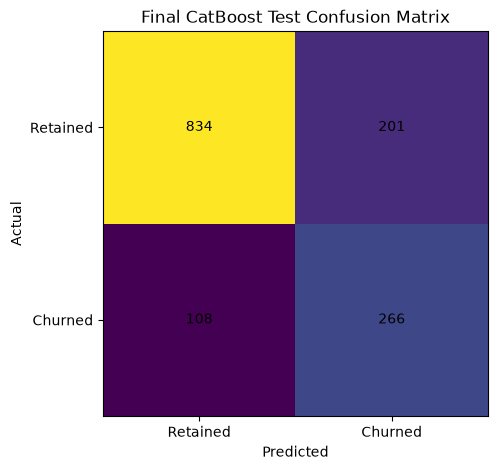

In [154]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(
    figsize=(5, 5)
)

ax.imshow(cm)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels([
    "Retained",
    "Churned"
])

ax.set_yticklabels([
    "Retained",
    "Churned"
])

ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

for i in range(2):
    for j in range(2):
        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.title(
    "Final CatBoost Test Confusion Matrix"
)

plt.show()

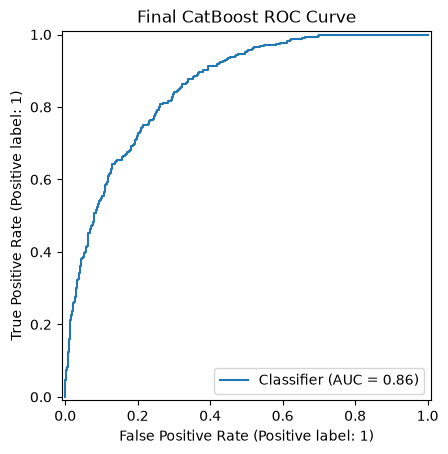

In [155]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    test_prob
)

plt.title(
    "Final CatBoost ROC Curve"
)

plt.show()

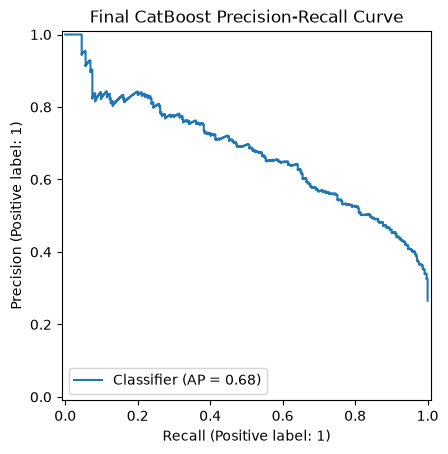

In [156]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(
    y_test,
    test_prob
)

plt.title(
    "Final CatBoost Precision-Recall Curve"
)

plt.show()

In [157]:
validation_results = {
    "Precision": 0.6032,
    "Recall": 0.7525,
    "F1": 0.6696
}

In [158]:
comparison_df = pd.DataFrame([
    {
        "Dataset": "Validation",
        "Precision": 0.6032,
        "Recall": 0.7525,
        "F1": 0.6696
    },
    {
        "Dataset": "Test",
        "Precision": final_metrics["Precision"],
        "Recall": final_metrics["Recall"],
        "F1": final_metrics["F1"]
    }
])

comparison_df.round(4)

,Dataset,Precision,Recall,F1
0,Validation,0.6032,0.7525,0.6696
1,Test,0.5696,0.7112,0.6326


In [159]:
print("FINAL MODEL")
print("-" * 40)

print("Algorithm   : Tuned CatBoost")
print("Threshold   :", FINAL_THRESHOLD)

print(
    "Accuracy    :",
    round(final_metrics["Accuracy"], 4)
)

print(
    "Precision   :",
    round(final_metrics["Precision"], 4)
)

print(
    "Recall      :",
    round(final_metrics["Recall"], 4)
)

print(
    "F1          :",
    round(final_metrics["F1"], 4)
)

print(
    "ROC-AUC     :",
    round(final_metrics["ROC_AUC"], 4)
)

print(
    "PR-AUC      :",
    round(final_metrics["PR_AUC"], 4)
)

FINAL MODEL
----------------------------------------
Algorithm   : Tuned CatBoost
Threshold   : 0.35
Accuracy    : 0.7807
Precision   : 0.5696
Recall      : 0.7112
F1          : 0.6326
ROC-AUC     : 0.8551
PR-AUC      : 0.6765
